11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step
Training dataset shape: (60000, 28, 28)
Testing dataset shape : (10000, 28, 28)


c:\Users\rauna\OneDrive\Desktop\BT23F05F048\generative-ai-practicals\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



>>> Training Discriminative Model (Classifier)...
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8964 - loss: 0.3800 - val_accuracy: 0.9560 - val_loss: 0.1662
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9505 - loss: 0.1739 - val_accuracy: 0.9658 - val_loss: 0.1239
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9635 - loss: 0.1272 - val_accuracy: 0.9738 - val_loss: 0.1002

Discriminator Evaluation Accuracy: 0.9671

>>> Training Generative Model (Autoencoder)...
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0466 - val_loss: 0.0254
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0205 - val_loss: 0.0172
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0158 - val_loss: 0.0145
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


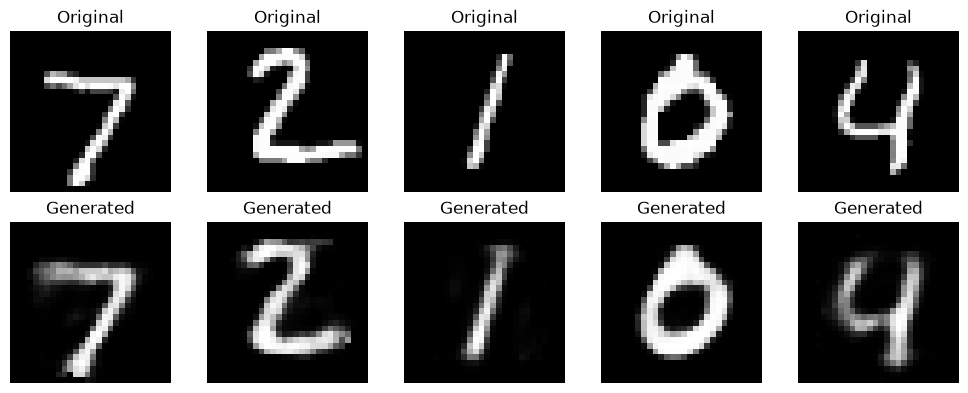

In [1]:
# Roll No: BT23F05F060

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, models, layers

# ==================================================
# 1. Dataset Loading & Preprocessing
# ==================================================
(train_imgs, train_lbls), (test_imgs, test_lbls) = datasets.mnist.load_data()

# Normalize pixel values to the range [0.0, 1.0]
train_imgs = train_imgs.astype("float32") / 255.0
test_imgs = test_imgs.astype("float32") / 255.0

print(f"Training dataset shape: {train_imgs.shape}")
print(f"Testing dataset shape : {test_imgs.shape}")

# ==================================================
# 2. Discriminative Model Setup & Training
# ==================================================
discriminator = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

discriminator.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n>>> Training Discriminative Model (Classifier)...")
discriminator.fit(
    train_imgs, train_lbls,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

_, disc_accuracy = discriminator.evaluate(test_imgs, test_lbls, verbose=0)
print(f"\nDiscriminator Evaluation Accuracy: {disc_accuracy:.4f}")

# ==================================================
# 3. Generative Model Setup & Training (Autoencoder)
# ==================================================
generator = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),

    # Encoder part
    layers.Dense(128, activation="relu"),
    layers.Dense(32, activation="relu"),

    # Decoder part
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid"),

    layers.Reshape((28, 28))
])

generator.compile(optimizer="adam", loss="mse")

print("\n>>> Training Generative Model (Autoencoder)...")
generator.fit(
    train_imgs, train_imgs,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

# ==================================================
# 4. Generate/Reconstruct Images & Visualize
# ==================================================
generated_outputs = generator.predict(test_imgs[:5])

# Using Matplotlib's object-oriented approach for cleaner plotting
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for idx in range(5):
    # Top Row: Original Images
    axes[0, idx].imshow(test_imgs[idx], cmap="gray")
    axes[0, idx].axis("off")
    axes[0, idx].set_title("Original")

    # Bottom Row: Generated/Reconstructed Images
    axes[1, idx].imshow(generated_outputs[idx], cmap="gray")
    axes[1, idx].axis("off")
    axes[1, idx].set_title("Generated")

plt.tight_layout()
plt.show()